# Data Loading
The dataset consists of four classes of astronomical objects: **Cepheid, RR Lyrae (RRL), Delta Scuti (d-Sct), and Eclipsing Binaries (EB)**.

These arrays represent preprocessed light curves, where each sample corresponds to a fixed-length feature vector. All classes are combined into a single feature matrix \( X \), while a corresponding label vector \( y \) is constructed to identify the class of each instance.

In [31]:
import numpy as np
import matplotlib.pyplot as plt

Cepheid = np.loadtxt("Cepheid.txt", delimiter=',')
RRL     = np.loadtxt("RRL.txt",     delimiter=',')
dSct    = np.loadtxt("d-Sct.txt",   delimiter=',')
EB      = np.loadtxt("EB.txt",      delimiter=',')

print("Cepheid:", Cepheid.shape)
print("RRL:", RRL.shape)
print("d-Sct:", dSct.shape)
print("EB:", EB.shape)

Cepheid: (19672, 50)
RRL: (20047, 50)
d-Sct: (29499, 50)
EB: (94934, 50)


# Dataset Construction
After loading the data, the feature matrix \( X \) is created by vertically stacking the samples from all classes. The label vector \( y \) is constructed by assigning an integer identifier to each class.


In [32]:
X = np.vstack([Cepheid, RRL, dSct, EB])

y = np.array([0] * len(Cepheid) +
             [1] * len(RRL)     +
             [2] * len(dSct)    +
             [3] * len(EB))

print("X:", X.shape)
print("y:", y.shape)


X: (164152, 50)
y: (164152,)


# Data Preprocessing
Before training the models, the dataset is normalized using standard scaling. This transformation ensures that each feature has zero mean and unit variance, which is particularly important for distance-based models such as Support Vector Machines.

The dataset is then split into training and testing subsets using a stratified sampling strategy. This preserves the original class distribution in both subsets, ensuring a fair and representative evaluation of the models.

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, stratify=y, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (114906, 50)
Test: (49246, 50)


# Subsampling for SVM
Due to the **high computational complexity** of Support Vector Machines with RBF kernel, a subsampling strategy is applied to the training data.

A fixed number of samples per class is randomly selected using stratified resampling. This ensures that the reduced dataset remains balanced and representative of all classes.

This approach significantly reduces the computational cost of training the SVM while maintaining sufficient information for learning meaningful decision boundaries.

In [34]:
from sklearn.utils import resample

N = 4000  #samples per class

idx = np.hstack([
    resample(np.where(y_train == c)[0],
             n_samples=N, random_state=42)
    for c in [0, 1, 2, 3]
])

X_train_svm = X_train[idx]
y_train_svm = y_train[idx]

print("SVM dataset:", X_train_svm.shape)

SVM dataset: (16000, 50)


# Model Training

In [35]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import time

# SVM
start = time.time()
clf_svm = SVC(C=1, gamma='scale', kernel='rbf')
clf_svm.fit(X_train_svm, y_train_svm)
svm_time = time.time() - start

print("SVM trained in:", svm_time, "seconds")

# Random Forest
start = time.time()
clf_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
clf_rf.fit(X_train, y_train)
rf_time = time.time() - start

print("RF trained in:", rf_time, "seconds")

SVM trained in: 37.279844760894775 seconds
RF trained in: 296.44832849502563 seconds


# Model Evaluation
Both models are evaluated on the test set using standard classification metrics.

Accuracy measures the overall proportion of correctly classified instances. The macro F1-score is used as the primary metric, as it gives equal importance to all classes regardless of their frequency.

Additionally, confusion matrices and classification reports are generated to provide a detailed view of per-class performance, including precision and recall.


=== SVM ===
Accuracy: 0.6198269910246518
Macro F1: 0.3686622927050055
Confusion Matrix:
 [[  679   710   410  4103]
 [  614  2074   413  2913]
 [ 1123  1959   885  4883]
 [  495   850   249 26886]]
Classification Report:
               precision    recall  f1-score   support

           0       0.23      0.12      0.15      5902
           1       0.37      0.34      0.36      6014
           2       0.45      0.10      0.16      8850
           3       0.69      0.94      0.80     28480

    accuracy                           0.62     49246
   macro avg       0.44      0.38      0.37     49246
weighted avg       0.56      0.62      0.55     49246


=== Random Forest ===
Accuracy: 0.8496730698940016
Macro F1: 0.7522319642846746
Confusion Matrix:
 [[ 2631   505   848  1918]
 [  112  4150  1392   360]
 [  270   755  7258   567]
 [  494    33   149 27804]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.45      0.56      5902


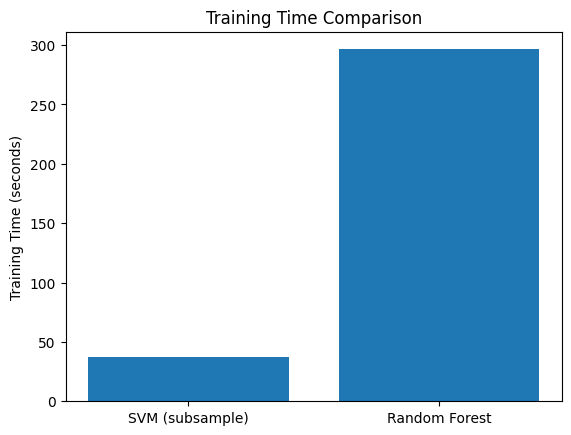

In [36]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

# SVM
y_pred_svm = clf_svm.predict(X_test)

# RF
y_pred_rf = clf_rf.predict(X_test)

print("\n=== SVM ===")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Macro F1:", f1_score(y_test, y_pred_svm, average='macro'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Macro F1:", f1_score(y_test, y_pred_rf, average='macro'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

models = ['SVM (subsample)', 'Random Forest']
times = [svm_time, rf_time]

plt.figure()
plt.bar(models, times)
plt.ylabel('Training Time (seconds)')
plt.title('Training Time Comparison')
plt.show()

It is important to note that the **SVM was not trained on the full dataset** due to its **computational limitations**. The training complexity of SVM with RBF kernel grows rapidly with the number of samples, making it impractical for large-scale datasets.

In contrast, Random Forest can efficiently handle the full dataset, making it a more suitable choice for large-scale classification problems such as the ELAsTiCC dataset.